# Shared code

In [4]:
# Import Packages
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier

In [5]:
features = ['Temperature(F)',
            'Wind_Chill(F)',
            'Humidity(%)',
            'Pressure(in)',
            'Visibility(mi)',
            'Wind_Speed(mph)',
            'Precipitation(in)',
            'Amenity',
            'Bump',
            'Crossing',
            'Give_Way',
            'Junction',
            'No_Exit',
            'Railway',
            'Roundabout',
            'Station',
            'Stop',
            'Traffic_Calming',
            'Traffic_Signal',
            'Turning_Loop',
            'Sunrise_Sunset',
            'Civil_Twilight',
            'Nautical_Twilight',
            'Astronomical_Twilight']
weather_features = ['Temperature(F)',
                    'Wind_Chill(F)',
                    'Humidity(%)',
                    'Pressure(in)',
                    'Visibility(mi)',
                    'Wind_Speed(mph)',
                    'Precipitation(in)',
                    'Sunrise_Sunset',
                    'Civil_Twilight',
                    'Nautical_Twilight',
                    'Astronomical_Twilight']
infrastructure_features = ['Amenity',
                           'Bump',
                           'Crossing',
                           'Give_Way',
                           'Junction',
                           'No_Exit',
                           'Railway',
                           'Roundabout',
                           'Station',
                           'Stop',
                           'Traffic_Calming',
                           'Traffic_Signal',
                           'Turning_Loop']
cols = ['Temperature(F)',
            'Wind_Chill(F)',
            'Humidity(%)',
            'Pressure(in)',
            'Visibility(mi)',
            'Wind_Speed(mph)',
            'Precipitation(in)',
            'Amenity',
            'Bump',
            'Crossing',
            'Give_Way',
            'Junction',
            'No_Exit',
            'Railway',
            'Roundabout',
            'Station',
            'Stop',
            'Traffic_Calming',
            'Traffic_Signal',
            'Turning_Loop',
            'Sunrise_Sunset',
            'Civil_Twilight',
            'Nautical_Twilight',
            'Astronomical_Twilight',
            'Severity',
            'Distance(mi)']

In [6]:
data = pd.read_csv('US_Accidents_March23.csv', usecols=cols)
data.dropna(inplace=True)
target_severity = data["Severity"]
target_distance = data["Distance(mi)"]
data = data.drop(["Severity", "Distance(mi)"], axis=1)

In [7]:
# Mask the data to only include weather-related features
weather_data = data[weather_features]
infrastructure_data = data[infrastructure_features]

In [8]:
def clean_continuous(data):
  """Clean the data in the input by describing outliers as lying outside of 1.5 times the inter-quartile range (IQR).
  Some data, like that of the Pressure column, is not sufficiently cleaned, and other columns are over-cleaned, removing
  valid values. These columns are cleaned by hard-coding."""
  cleaned = data.copy()

  cleaned.loc[cleaned['Visibility(mi)'] > 10.0, 'Visibility(mi)'] = 10.0
  cleaned.loc[cleaned['Temperature(F)'] > 134.4, 'Temperature(F)'] = cleaned.loc[cleaned['Temperature(F)'] < 134.4, 'Temperature(F)'].mean()
  cleaned.loc[cleaned['Wind_Chill(F)'] > 134.4, 'Wind_Chill(F)'] = cleaned.loc[cleaned['Wind_Chill(F)'] < 134.4, 'Wind_Chill(F)'].mean()

  other_cols = [col for col in cleaned.columns if col not in ('Visibility(mi)', 'Temperature(F)', 'Wind_Chill(F)')]

  for col in other_cols:
    if cleaned[col].dtype != object:
      q1 = cleaned[col].quantile(0.25)
      q3 = cleaned[col].quantile(0.75)
      iqr = q3 - q1

      non_outliers = cleaned.loc[(cleaned[col] >= (q1 - 1.5*iqr)) & (cleaned[col] <= (q3 + 1.5*iqr)), col].mean()
      cleaned.loc[(cleaned[col] < (q1 - 1.5*iqr)) | (cleaned[col] > (q3 + 1.5*iqr)), [col]] = non_outliers

  return cleaned

In [9]:
def plot_eff(true, predict, alpha=0.01):
    """Plots the effectivity of model performance by comparing actual and predicted values

    Parameters:
        true (ndarray): The true values
        predict (ndarray): The predicted values
    """
    # Find the absolute maximum and minimum values among all the input data
    top = max([max(true), max(predict)])
    bottom = min([min(true), min(predict)])
    # Plot the ideral fit line
    plt.plot([bottom, top], [bottom, top], "r--", label="Ideal Fit")
    # Plot the actual fit points
    plt.plot(true, predict, "go", alpha=alpha, label="Actual Fit")

    # Format and show the plot
    plt.xlabel("True Value")
    plt.ylabel("Predicted Value")
    plt.show()

In [10]:
weather_data = data[weather_features]
weather_data_new = weather_data.drop(['Sunrise_Sunset',
                                      'Civil_Twilight',
                                      'Nautical_Twilight',
                                      'Astronomical_Twilight'], axis=1)
cleaned_weather = clean_continuous(weather_data_new)

In [11]:
# Split data into training and test data
train_size = int(1e6)
X_severity_train, X_severity_test, y_severity_train, y_severity_test = train_test_split(cleaned_weather, target_severity, train_size = train_size)
X_distance_train, X_distance_test, y_distance_train, y_distance_test = train_test_split(cleaned_weather, target_distance, train_size = train_size)

CPU times: user 4.33 s, sys: 19.7 ms, total: 4.35 s
Wall time: 4.56 s
CPU times: user 1.87 s, sys: 150 ms, total: 2.02 s
Wall time: 2.05 s
76.95% Correctly Classified


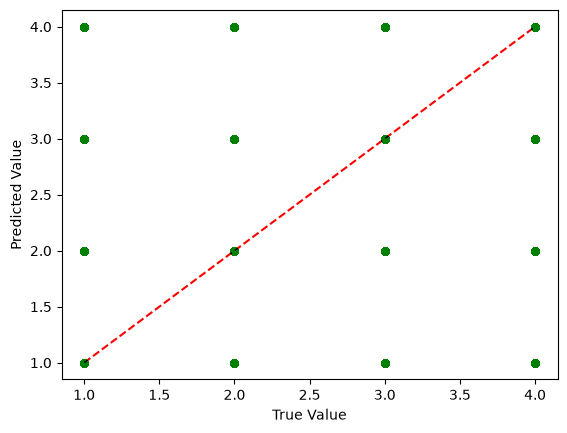

CPU times: user 4.44 s, sys: 60.9 ms, total: 4.5 s
Wall time: 4.72 s


In [12]:
# Decision Tree Classifier
tree_class = DecisionTreeClassifier() # Create the decision tree classifier object
%time tree_class.fit(X_severity_train, y_severity_train)  # Fit the training data
%time y_severity_pred = tree_class.predict(X_severity_test) # Predict for the test data

# Calculate effectiveness
CM = confusion_matrix(y_severity_test, y_severity_pred) # Create the confusion matrix
correct = np.sum(np.diagonal(CM)) # Calculate how many were correctly classified by summing the diagonal of the confusion matrix
total = np.sum(np.sum(CM))  # Calculate the total number of entries by summing the confusion matrix
print(f"{round(100*(correct/total), 2)}% Correctly Classified") # Print the prediction effectivity

%time plot_eff(y_severity_test, y_severity_pred, alpha=0.005)

CPU times: user 15min 55s, sys: 1.4 s, total: 15min 56s
Wall time: 1min
CPU times: user 25.3 s, sys: 126 ms, total: 25.4 s
Wall time: 1.93 s
CPU times: user 941 ms, sys: 105 ms, total: 1.05 s
Wall time: 986 ms
85.24% Correctly Classified


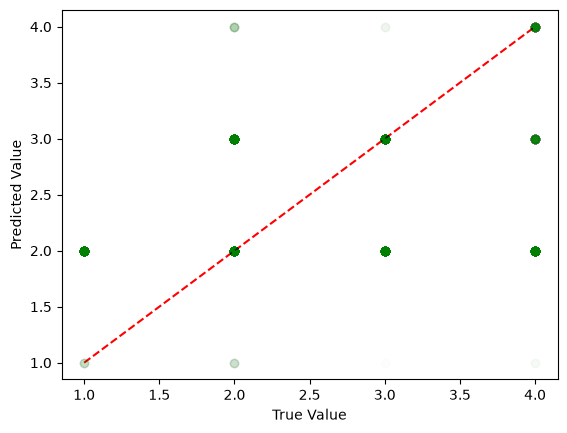

In [13]:
# Decision Tree Classifier
xgb_class = XGBClassifier() # Create the decision tree classifier object
%time xgb_class.fit(X_severity_train, y_severity_train - 1)  # Fit the training data
%time y_severity_pred = xgb_class.predict(X_severity_test) # Predict for the test data

# Calculate effectiveness
%time CM = confusion_matrix(y_severity_test, y_severity_pred + 1) # Create the confusion matrix
correct = np.sum(np.diagonal(CM)) # Calculate how many were correctly classified by summing the diagonal of the confusion matrix
total = np.sum(np.sum(CM))  # Calculate the total number of entries by summing the confusion matrix
print(f"{round(100*(correct/total), 2)}% Correctly Classified") # Print the prediction effectivity

plot_eff(y_severity_test, y_severity_pred + 1)

CPU times: user 3.97 s, sys: 96.4 ms, total: 4.07 s
Wall time: 4.02 s
CPU times: user 2.87 s, sys: 67.6 ms, total: 2.94 s
Wall time: 3 s
5.727034356247111
-0.719875912671595


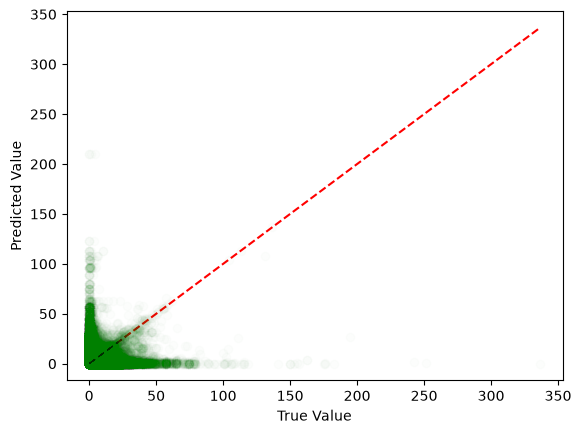

In [14]:
n = len(y_distance_test)
tree_reg = DecisionTreeRegressor()
%time tree_reg.fit(X_distance_train, y_distance_train)
%time y_distance_pred = tree_reg.predict(X_distance_test)
mse = mean_squared_error(y_distance_pred, y_distance_test)
print(mse)
print(r2_score(y_distance_pred, y_distance_test))
plot_eff(y_distance_test, y_distance_pred)

CPU times: user 4min, sys: 458 ms, total: 4min 1s
Wall time: 15.2 s
CPU times: user 5.24 s, sys: 7.83 ms, total: 5.24 s
Wall time: 373 ms
3.293834166734277
-26.226902069756886


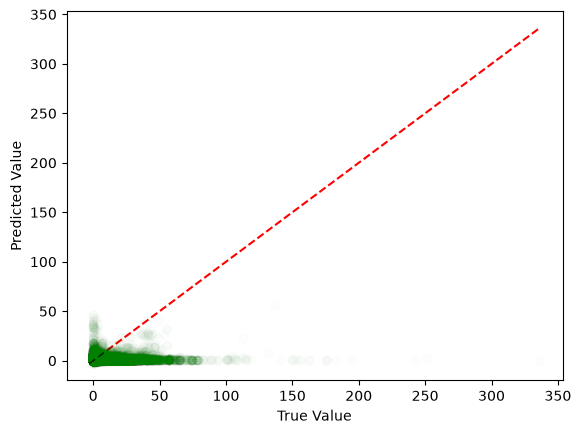

CPU times: user 5.28 s, sys: 68.1 ms, total: 5.34 s
Wall time: 5.57 s


In [15]:
n = len(y_distance_test)
xgb_reg = XGBRegressor()
%time xgb_reg.fit(X_distance_train, y_distance_train)
%time y_distance_pred = xgb_reg.predict(X_distance_test)
mse = mean_squared_error(y_distance_pred, y_distance_test)
print(mse)
print(r2_score(y_distance_pred, y_distance_test))
%time plot_eff(y_distance_test, y_distance_pred)